<a href="https://colab.research.google.com/github/apsharma07/AI-ML-DL-Hacktoberfest2024-WB/blob/temp/projectavinash.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dataset Sample:

   residual_energy  node_speed    distance  link_quality  queue_length  \
0        43.708611   13.454060  162.415982      0.922220            20   
1        95.564288   15.933628   43.924204      0.572824            39   
2        75.879455    5.009358  218.226246      0.752419             3   
3        63.879264   12.497482  153.665944      0.492443             5   
4        24.041678   11.434920   40.143767      0.667031             1   

       delay  hop_count  route_stability  
0  90.013088          3        46.643619  
1  34.472550          6        56.873438  
2  74.672410          2        56.384650  
3  76.220884          8        41.936266  
4  65.404943         13        31.386570  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1835.4102 - mae: 40.5464 - val_loss: 1456.6288 - val_mae: 35.8117
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 831.6965 - mae: 25.0994 - val_loss: 386.3231 - val_mae: 16.4422
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 265.9620 - mae: 13.2046 - val_loss: 185.8548 - val_mae: 11.2045
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 191.6981 - mae: 11.4015 - val_loss: 172.5792 - val_mae: 10.7887
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 187.3871 - mae: 11.2172 - val_loss: 164.1910 - val_mae: 10.4966
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 171.5270 - mae: 10.6557 - val_loss: 142.0184 - val_mae: 9.7191
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 131.2531 - mae: 9.2403 - val_loss: 81.9591 - val_mae: 7.1553
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 65.4230 - mae: 6.1319 - val_loss: 22.4770 - val_mae: 3.2548
Epoch 9/20
75/75 ━━━━━━━━━━━━

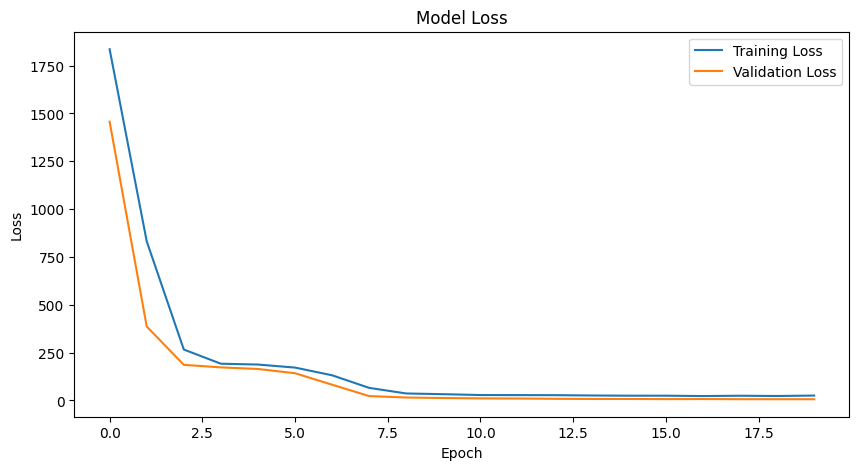


Best Route Selected:
Route Index: 552
Predicted Stability Score: 67.28432

Model saved successfully!


In [1]:
# ============================================================
# Deep Learning Based Energy-Aware Routing for MANET
# Using LSTM for Route Stability & Energy Prediction
# ============================================================

# Install Required Libraries:
# pip install tensorflow pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ============================================================
# STEP 1: GENERATE SIMULATED MANET DATASET
# ============================================================

np.random.seed(42)

num_samples = 3000

data = {
    "residual_energy": np.random.uniform(10, 100, num_samples),
    "node_speed": np.random.uniform(0, 20, num_samples),
    "distance": np.random.uniform(1, 250, num_samples),
    "link_quality": np.random.uniform(0.1, 1.0, num_samples),
    "queue_length": np.random.randint(1, 50, num_samples),
    "delay": np.random.uniform(1, 100, num_samples),
    "hop_count": np.random.randint(1, 15, num_samples),
}

df = pd.DataFrame(data)

# ============================================================
# TARGET VARIABLE
# Higher value = Better Route Stability
# ============================================================

df["route_stability"] = (
    (df["residual_energy"] * 0.4)
    + ((1 / (df["node_speed"] + 1)) * 100 * 0.2)
    + (df["link_quality"] * 100 * 0.3)
    + ((1 / (df["delay"] + 1)) * 100 * 0.1)
)

print("\nDataset Sample:\n")
print(df.head())

# ============================================================
# STEP 2: FEATURE SELECTION
# ============================================================

X = df.drop("route_stability", axis=1)
y = df["route_stability"]

# ============================================================
# STEP 3: NORMALIZATION
# ============================================================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 4: RESHAPE FOR LSTM
# LSTM expects 3D input:
# [samples, time_steps, features]
# ============================================================

X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# ============================================================
# STEP 5: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_lstm,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# STEP 6: BUILD LSTM MODEL
# ============================================================

model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(units=32))

model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

# ============================================================
# STEP 7: COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# ============================================================
# STEP 8: TRAIN MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ============================================================
# STEP 9: EVALUATE MODEL
# ============================================================

loss, mae = model.evaluate(X_test, y_test)

print("\nModel Evaluation")
print("Loss:", loss)
print("Mean Absolute Error:", mae)

# ============================================================
# STEP 10: PREDICTION
# ============================================================

predictions = model.predict(X_test)

print("\nPredicted Route Stability:\n")
print(predictions[:10])

# ============================================================
# STEP 11: VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ============================================================
# STEP 12: SELECT BEST ROUTE
# ============================================================

best_route_index = np.argmax(predictions)

print("\nBest Route Selected:")
print("Route Index:", best_route_index)
print("Predicted Stability Score:", predictions[best_route_index][0])

# ============================================================
# OPTIONAL:
# Save Model
# ============================================================

model.save("manet_energy_aware_lstm_model.h5")

print("\nModel saved successfully!")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1833.9769 - mae: 40.5289 - val_loss: 1438.6653 - val_mae: 35.5657
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 752.2175 - mae: 23.4529 - val_loss: 313.6198 - val_mae: 14.6644
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 235.5294 - mae: 12.4380 - val_loss: 177.2912 - val_mae: 10.9364
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 192.5650 - mae: 11.4233 - val_loss: 169.1654 - val_mae: 10.6612
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 183.2347 - mae: 11.0509 - val_loss: 159.0125 - val_mae: 10.3094
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 164.8197 - mae: 10.5109 - val_loss: 133.1207 - val_mae: 9.3842
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 122.4945 - mae: 8.9001 - val_loss: 71.8275 - val_mae: 6.6455
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 55.9548 - mae: 5.6290 - val_loss: 22.0892 - val_mae: 3.1473
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━

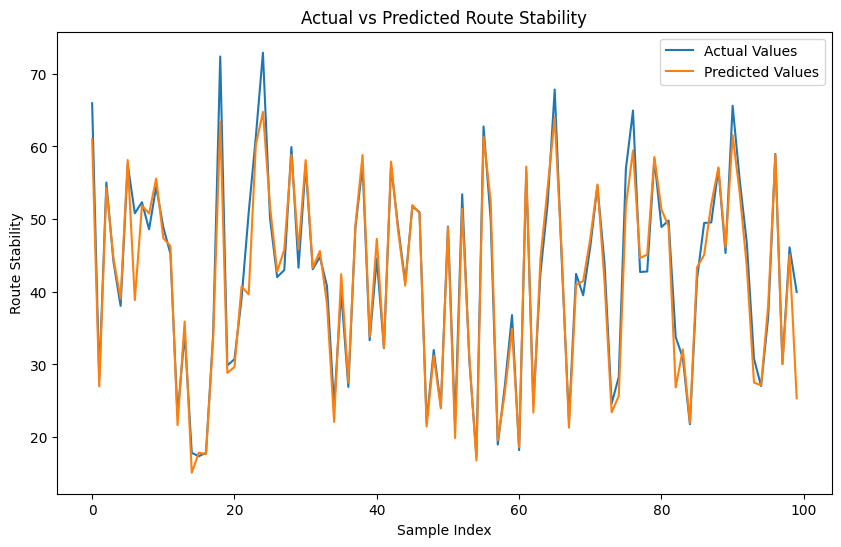

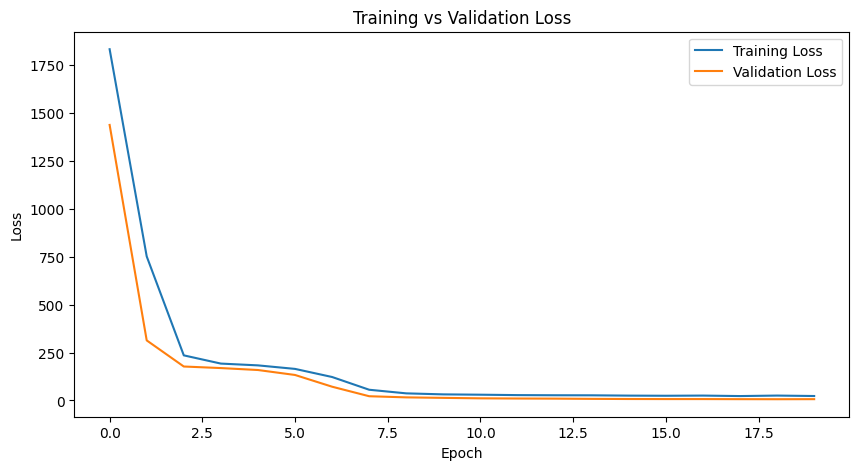


=============== BEST ROUTE ===============
Best Route Index: 552
Predicted Stability Score: 66.09643

Model saved successfully!

Excellent Model Performance


In [2]:
# ============================================================
# Deep Learning Based Energy-Aware Routing for MANET
# WITH ACCURACY VALIDATION
# ============================================================

# Install:
# pip install tensorflow pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ============================================================
# STEP 1: GENERATE SIMULATED DATASET
# ============================================================

np.random.seed(42)

num_samples = 3000

data = {
    "residual_energy": np.random.uniform(10, 100, num_samples),
    "node_speed": np.random.uniform(0, 20, num_samples),
    "distance": np.random.uniform(1, 250, num_samples),
    "link_quality": np.random.uniform(0.1, 1.0, num_samples),
    "queue_length": np.random.randint(1, 50, num_samples),
    "delay": np.random.uniform(1, 100, num_samples),
    "hop_count": np.random.randint(1, 15, num_samples),
}

df = pd.DataFrame(data)

# ============================================================
# TARGET VARIABLE
# ============================================================

df["route_stability"] = (
    (df["residual_energy"] * 0.4)
    + ((1 / (df["node_speed"] + 1)) * 100 * 0.2)
    + (df["link_quality"] * 100 * 0.3)
    + ((1 / (df["delay"] + 1)) * 100 * 0.1)
)

# ============================================================
# STEP 2: FEATURE SELECTION
# ============================================================

X = df.drop("route_stability", axis=1)
y = df["route_stability"]

# ============================================================
# STEP 3: NORMALIZATION
# ============================================================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 4: RESHAPE FOR LSTM
# ============================================================

X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# ============================================================
# STEP 5: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_lstm,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# STEP 6: BUILD MODEL
# ============================================================

model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

# ============================================================
# STEP 7: COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# ============================================================
# STEP 8: TRAIN MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ============================================================
# STEP 9: PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# Flatten arrays
y_pred = y_pred.flatten()

# ============================================================
# STEP 10: VALIDATION METRICS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# ============================================================
# ACCURACY CALCULATION
# ============================================================
# Since this is regression, we estimate accuracy using R² score

accuracy = r2 * 100

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n================ MODEL VALIDATION ================\n")

print(f"Mean Absolute Error (MAE): {mae:.4f}")

print(f"Mean Squared Error (MSE): {mse:.4f}")

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print(f"R² Score: {r2:.4f}")

print(f"Estimated Accuracy: {accuracy:.2f}%")

# ============================================================
# STEP 11: VISUALIZE ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(y_test.values[:100], label="Actual Values")

plt.plot(y_pred[:100], label="Predicted Values")

plt.title("Actual vs Predicted Route Stability")

plt.xlabel("Sample Index")

plt.ylabel("Route Stability")

plt.legend()

plt.show()

# ============================================================
# STEP 12: LOSS GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# ============================================================
# STEP 13: BEST ROUTE SELECTION
# ============================================================

best_route_index = np.argmax(y_pred)

print("\n=============== BEST ROUTE ===============")

print("Best Route Index:", best_route_index)

print("Predicted Stability Score:", y_pred[best_route_index])

# ============================================================
# STEP 14: SAVE MODEL
# ============================================================

model.save("manet_energy_aware_model.h5")

print("\nModel saved successfully!")

# ============================================================
# OPTIONAL PERFORMANCE INTERPRETATION
# ============================================================

if accuracy > 90:
    print("\nExcellent Model Performance")
elif accuracy > 75:
    print("\nGood Model Performance")
elif accuracy > 60:
    print("\nAverage Model Performance")
else:
    print("\nModel Needs Improvement")


Sample Dataset:

   residual_energy  node_speed    distance  link_quality  queue_length  \
0        43.708611   13.454060  162.415982      0.922220            20   
1        95.564288   15.933628   43.924204      0.572824            39   
2        75.879455    5.009358  218.226246      0.752419             3   
3        63.879264   12.497482  153.665944      0.492443             5   
4        24.041678   11.434920   40.143767      0.667031             1   

       delay  hop_count  route_stability  
0  90.013088          3        46.643619  
1  34.472550          6        56.873438  
2  74.672410          2        56.384650  
3  76.220884          8        41.936266  
4  65.404943         13        31.386570  

================ FOLD 1 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MAE  : 1.9453
MSE  : 8.7458
RMSE : 2.9573
R²   : 0.9526
Accuracy: 95.26%

================ FOLD 2 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MAE  : 1.8579
MSE  : 7.3534
RMSE : 2.7117
R²   : 0.9580
Accuracy: 95.80%

================ FOLD 3 ================



...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MAE  : 1.9439
MSE  : 7.2568
RMSE : 2.6938
R²   : 0.9636
Accuracy: 96.36%

================ FOLD 4 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MAE  : 2.0990
MSE  : 7.9455
RMSE : 2.8188
R²   : 0.9609
Accuracy: 96.09%

================ FOLD 5 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MAE  : 3.2403
MSE  : 21.6087
RMSE : 4.6485
R²   : 0.8831
Accuracy: 88.31%

      FINAL K-FOLD CROSS VALIDATION RESULT
Average MAE  : 2.2173
Average MSE  : 10.5820
Average RMSE : 3.1660
Average R²   : 0.9437
Average Accuracy: 94.37%


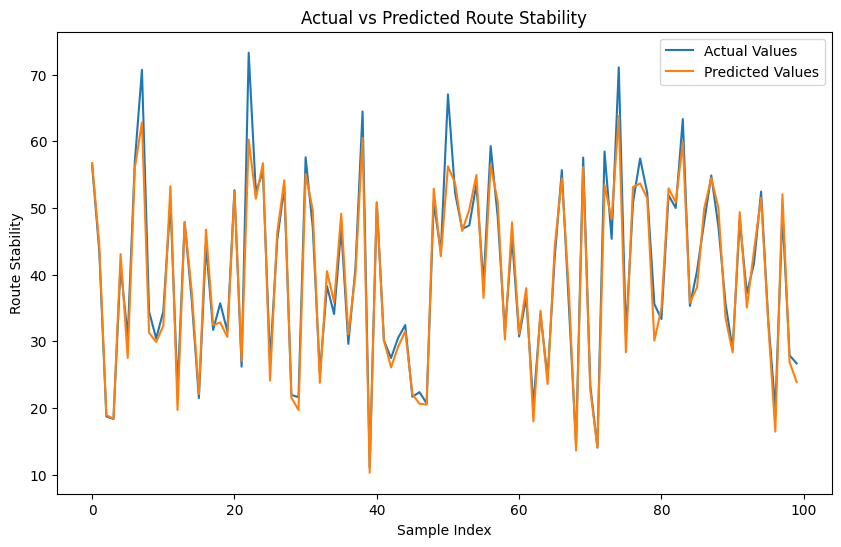

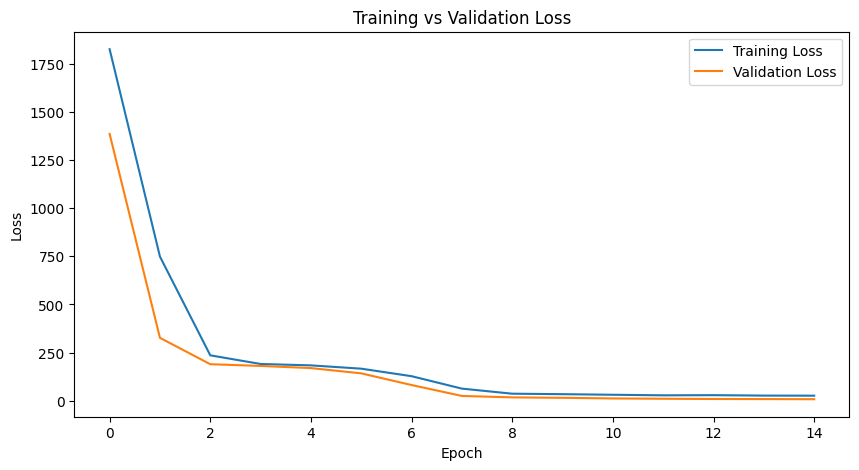


================ RANDOM INPUT TEST ================

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Input Parameters:

Residual Energy : 75.0
Node Speed      : 5.0
Distance        : 120.0
Link Quality    : 0.85
Queue Length    : 10.0
Delay           : 20.0
Hop Count       : 4.0

Predicted Route Stability Score: 58.63
Route Status: Moderately Stable

================ MULTIPLE RANDOM TESTS ================

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Test Case 1
----------------------------------
Residual Energy : 20.18
Node Speed      : 2.17
Distance        : 181.36
Link Quality    : 0.23
Queue Length    : 1.0
Delay           : 74.39
Hop Count       : 8.0
Predicted Stability Score: 19.16


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Test Case 2
----------------------------------
Residual Energy : 12.59
Node Speed      : 0.00
Distance        : 64.80
Link Quality    : 0.87
Queue Length    : 7.0
Delay           : 40.38
Hop Count       : 13.0
Predicted Stability Score: 39.47
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Test Case 3
----------------------------------
Residual Energy : 10.18
Node Speed      : 11.09
Distance        : 60.25
Link Quality    : 0.77
Queue Length    : 46.0
Delay           : 68.18
Hop Count       : 12.0
Predicted Stability Score: 29.28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Test Case 4
----------------------------------
Residual Energy : 73.18
Node Speed      : 0.90
Distance        : 97.01
Link Quality    : 0.41
Queue Length    : 25.0
Delay           : 89.26
Hop Count       : 6.0
Predicted Stability Score: 49.57
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step



Test Case 5
----------------------------------
Residual Energy : 85.19
Node Speed      : 1.83
Distance        : 14.98
Link Quality    : 0.43
Queue Length    : 37.0
Delay           : 8.67
Hop Count       : 3.0
Predicted Stability Score: 54.02

Model saved successfully!

Excellent Model Performance


In [3]:
# ============================================================
# Deep Learning Based Energy-Aware Routing for MANET
# COMPLETE CODE WITH:
# 1. Dataset Generation
# 2. LSTM Model
# 3. K-Fold Cross Validation
# 4. Accuracy Validation
# 5. Random Input Testing
# ============================================================

# Install libraries:
# pip install tensorflow pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ============================================================
# STEP 1: GENERATE SIMULATED MANET DATASET
# ============================================================

np.random.seed(42)

num_samples = 3000

data = {
    "residual_energy": np.random.uniform(10, 100, num_samples),
    "node_speed": np.random.uniform(0, 20, num_samples),
    "distance": np.random.uniform(1, 250, num_samples),
    "link_quality": np.random.uniform(0.1, 1.0, num_samples),
    "queue_length": np.random.randint(1, 50, num_samples),
    "delay": np.random.uniform(1, 100, num_samples),
    "hop_count": np.random.randint(1, 15, num_samples),
}

df = pd.DataFrame(data)

# ============================================================
# TARGET VARIABLE (Route Stability Formula)
# ============================================================

df["route_stability"] = (
    (df["residual_energy"] * 0.4)
    + ((1 / (df["node_speed"] + 1)) * 100 * 0.2)
    + (df["link_quality"] * 100 * 0.3)
    + ((1 / (df["delay"] + 1)) * 100 * 0.1)
)

print("\nSample Dataset:\n")
print(df.head())

# ============================================================
# STEP 2: FEATURE SELECTION
# ============================================================

X = df.drop("route_stability", axis=1)
y = df["route_stability"]

# ============================================================
# STEP 3: NORMALIZATION
# ============================================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 4: RESHAPE FOR LSTM
# ============================================================

X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# ============================================================
# STEP 5: K-FOLD CROSS VALIDATION
# ============================================================

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = []
mse_scores = []
rmse_scores = []
r2_scores = []

best_model = None
best_r2 = -1
best_X_test = None
best_y_test = None
best_y_pred = None
best_history = None

fold = 1

for train_index, test_index in kfold.split(X_lstm):

    print(f"\n================ FOLD {fold} ================\n")

    X_train, X_test = X_lstm[train_index], X_lstm[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # ============================================================
    # BUILD MODEL
    # ============================================================

    model = Sequential()

    model.add(
        LSTM(
            units=64,
            return_sequences=True,
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )

    model.add(Dropout(0.2))

    model.add(LSTM(32))

    model.add(Dropout(0.2))

    model.add(Dense(16, activation='relu'))

    model.add(Dense(1))

    # ============================================================
    # COMPILE MODEL
    # ============================================================

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    # ============================================================
    # TRAIN MODEL
    # ============================================================

    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0
    )

    # ============================================================
    # PREDICT
    # ============================================================

    y_pred = model.predict(X_test)
    y_pred = y_pred.flatten()

    # ============================================================
    # METRICS
    # ============================================================

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    mse_scores.append(mse)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"Accuracy: {r2*100:.2f}%")

    # Save best model
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
        best_history = history

    fold += 1

# ============================================================
# STEP 6: FINAL AVERAGE RESULTS
# ============================================================

avg_mae = np.mean(mae_scores)
avg_mse = np.mean(mse_scores)
avg_rmse = np.mean(rmse_scores)
avg_r2 = np.mean(r2_scores)
avg_accuracy = avg_r2 * 100

print("\n==============================================")
print("      FINAL K-FOLD CROSS VALIDATION RESULT")
print("==============================================")

print(f"Average MAE  : {avg_mae:.4f}")
print(f"Average MSE  : {avg_mse:.4f}")
print(f"Average RMSE : {avg_rmse:.4f}")
print(f"Average R²   : {avg_r2:.4f}")
print(f"Average Accuracy: {avg_accuracy:.2f}%")

# ============================================================
# STEP 7: ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(best_y_test.values[:100], label="Actual Values")
plt.plot(best_y_pred[:100], label="Predicted Values")

plt.title("Actual vs Predicted Route Stability")
plt.xlabel("Sample Index")
plt.ylabel("Route Stability")
plt.legend()

plt.show()

# ============================================================
# STEP 8: LOSS GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ============================================================
# STEP 9: RANDOM INPUT TEST
# ============================================================

print("\n================ RANDOM INPUT TEST ================\n")

random_input = np.array([[
    75,     # residual_energy
    5,      # node_speed
    120,    # distance
    0.85,   # link_quality
    10,     # queue_length
    20,     # delay
    4       # hop_count
]])

# Normalize
random_input_scaled = scaler.transform(random_input)

# Reshape
random_input_scaled = random_input_scaled.reshape(
    (random_input_scaled.shape[0], 1, random_input_scaled.shape[1])
)

# Predict
prediction = best_model.predict(random_input_scaled)
predicted_score = prediction[0][0]

print("Input Parameters:\n")

print(f"Residual Energy : {random_input[0][0]}")
print(f"Node Speed      : {random_input[0][1]}")
print(f"Distance        : {random_input[0][2]}")
print(f"Link Quality    : {random_input[0][3]}")
print(f"Queue Length    : {random_input[0][4]}")
print(f"Delay           : {random_input[0][5]}")
print(f"Hop Count       : {random_input[0][6]}")

print("\nPredicted Route Stability Score:", round(predicted_score, 2))

if predicted_score > 70:
    print("Route Status: Highly Stable & Energy Efficient")
elif predicted_score > 50:
    print("Route Status: Moderately Stable")
else:
    print("Route Status: Poor Route Stability")

# ============================================================
# STEP 10: MULTIPLE RANDOM TESTS
# ============================================================

print("\n================ MULTIPLE RANDOM TESTS ================\n")

for i in range(5):

    sample = np.array([[
        np.random.uniform(10, 100),
        np.random.uniform(0, 20),
        np.random.uniform(1, 250),
        np.random.uniform(0.1, 1.0),
        np.random.randint(1, 50),
        np.random.uniform(1, 100),
        np.random.randint(1, 15)
    ]])

    sample_scaled = scaler.transform(sample)
    sample_scaled = sample_scaled.reshape(
        (sample_scaled.shape[0], 1, sample_scaled.shape[1])
    )

    pred = best_model.predict(sample_scaled)

    print(f"\nTest Case {i+1}")
    print("----------------------------------")
    print(f"Residual Energy : {sample[0][0]:.2f}")
    print(f"Node Speed      : {sample[0][1]:.2f}")
    print(f"Distance        : {sample[0][2]:.2f}")
    print(f"Link Quality    : {sample[0][3]:.2f}")
    print(f"Queue Length    : {sample[0][4]}")
    print(f"Delay           : {sample[0][5]:.2f}")
    print(f"Hop Count       : {sample[0][6]}")
    print(f"Predicted Stability Score: {pred[0][0]:.2f}")

# ============================================================
# STEP 11: SAVE MODEL
# ============================================================

best_model.save("manet_energy_aware_model.h5")

print("\nModel saved successfully!")

# ============================================================
# PERFORMANCE INTERPRETATION
# ============================================================

if avg_accuracy > 90:
    print("\nExcellent Model Performance")
elif avg_accuracy > 75:
    print("\nGood Model Performance")
elif avg_accuracy > 60:
    print("\nAverage Model Performance")
else:
    print("\nModel Needs Improvement")


Sample Dataset:

   residual_energy  node_speed    distance  link_quality  queue_length  \
0        43.708611   13.454060  162.415982      0.922220            20   
1        95.564288   15.933628   43.924204      0.572824            39   
2        75.879455    5.009358  218.226246      0.752419             3   
3        63.879264   12.497482  153.665944      0.492443             5   
4        24.041678   11.434920   40.143767      0.667031             1   

       delay  hop_count  route_stability  
0  90.013088          3        38.865022  
1  34.472550          6        45.219499  
2  74.672410          2        47.164855  
3  76.220884          8        34.169227  
4  65.404943         13        28.345346  

================ FOLD 1 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE  : 1.5448
MSE  : 5.2278
RMSE : 2.2864
R²   : 0.9539
Accuracy: 95.39%

================ FOLD 2 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE  : 1.5458
MSE  : 5.1693
RMSE : 2.2736
R²   : 0.9516
Accuracy: 95.16%

================ FOLD 3 ================



...

MAE  : 1.5499
MSE  : 4.3858
RMSE : 2.0942
R²   : 0.9641
Accuracy: 96.41%

================ FOLD 4 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE  : 1.4970
MSE  : 4.7062
RMSE : 2.1694
R²   : 0.9624
Accuracy: 96.24%

================ FOLD 5 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE  : 1.6558
MSE  : 5.1906
RMSE : 2.2783
R²   : 0.9539
Accuracy: 95.39%

      FINAL K-FOLD CROSS VALIDATION RESULT
Average MAE  : 1.5587
Average MSE  : 4.9359
Average RMSE : 2.2204
Average R²   : 0.9572
Average Accuracy: 95.72%


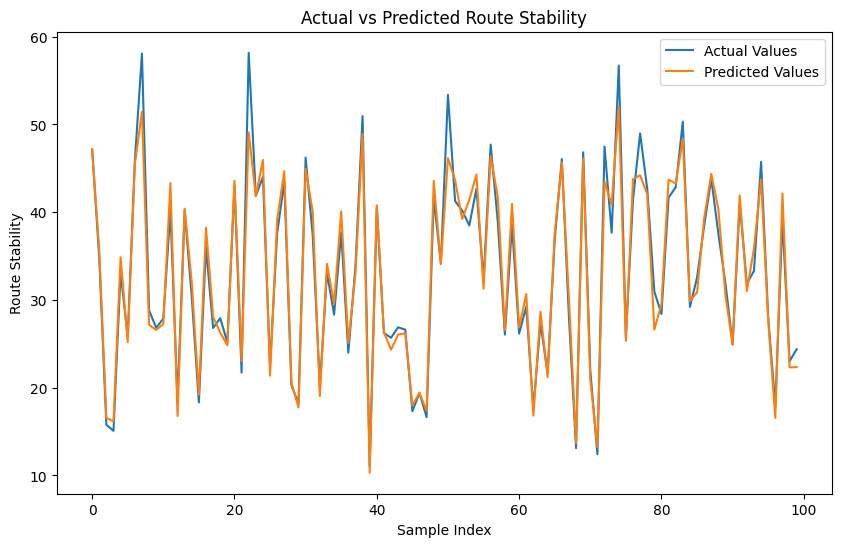

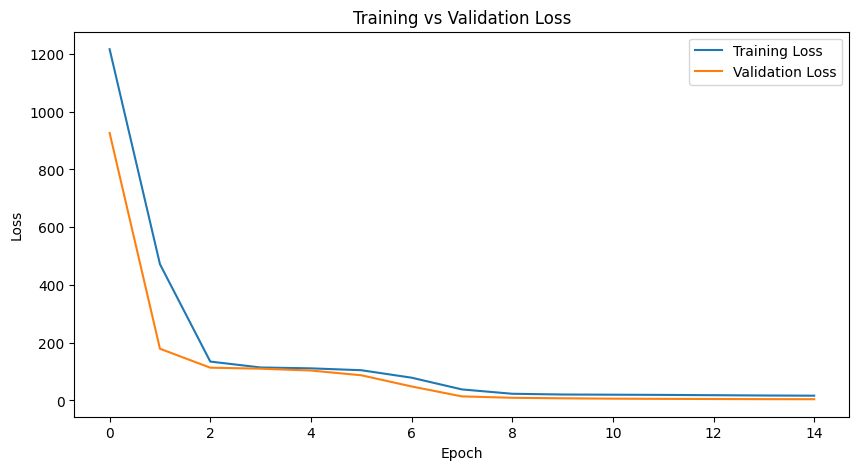


================ RANDOM INPUT TEST ================

Input Parameters:

Residual Energy : 85.19
Node Speed      : 1.83
Distance        : 14.98
Link Quality    : 0.43
Queue Length    : 37.0
Delay           : 8.67
Hop Count       : 3.0

Manual Formula Score: 44.65
Model Prediction Score: 43.91
Prediction Error: 0.74
Route Status: Moderately Stable

================ MULTIPLE RANDOM TESTS ================


Test Case 1
----------------------------------
Residual Energy : 20.18
Node Speed      : 2.17
Distance        : 181.36
Link Quality    : 0.23
Queue Length    : 1.0
Delay           : 74.39
Hop Count       : 8.0
Predicted Stability Score: 17.24


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida


Test Case 2
----------------------------------
Residual Energy : 12.59
Node Speed      : 0.00
Distance        : 64.80
Link Quality    : 0.87
Queue Length    : 7.0
Delay           : 40.38
Hop Count       : 13.0
Predicted Stability Score: 33.44

Test Case 3
----------------------------------
Residual Energy : 10.18
Node Speed      : 11.09
Distance        : 60.25
Link Quality    : 0.77
Queue Length    : 46.0
Delay           : 68.18
Hop Count       : 12.0
Predicted Stability Score: 24.82

Test Case 4
----------------------------------
Residual Energy : 73.18
Node Speed      : 0.90
Distance        : 97.01
Link Quality    : 0.41
Queue Length    : 25.0
Delay           : 89.26
Hop Count       : 6.0
Predicted Stability Score: 40.15

Test Case 5
----------------------------------
Residual Energy : 85.19
Node Speed      : 1.83
Distance        : 14.98
Link Quality    : 0.43
Queue Length    : 37.0
Delay           : 8.67
Hop Count       : 3.0
Predicted Stability Score: 43.85

Model saved successful

In [4]:
# ============================================================
# Deep Learning Based Energy-Aware Routing for MANET
# IMPROVED VERSION WITH:
# 1. Realistic Target Formula
# 2. LSTM Model
# 3. 5-Fold Cross Validation
# 4. Accuracy Validation
# 5. Random Input Testing
# ============================================================

# Install:
# pip install tensorflow pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ============================================================
# STEP 1: GENERATE SIMULATED MANET DATASET
# ============================================================

np.random.seed(42)

num_samples = 3000

data = {
    "residual_energy": np.random.uniform(10, 100, num_samples),
    "node_speed": np.random.uniform(0, 20, num_samples),
    "distance": np.random.uniform(1, 250, num_samples),
    "link_quality": np.random.uniform(0.1, 1.0, num_samples),
    "queue_length": np.random.randint(1, 50, num_samples),
    "delay": np.random.uniform(1, 100, num_samples),
    "hop_count": np.random.randint(1, 15, num_samples),
}

df = pd.DataFrame(data)

# ============================================================
# STEP 2: IMPROVED TARGET VARIABLE (Route Stability)
# Now ALL features contribute
# ============================================================

df["route_stability"] = (
    (df["residual_energy"] * 0.30)
    + ((1 / (df["node_speed"] + 1)) * 100 * 0.15)
    + (df["link_quality"] * 100 * 0.25)
    + ((1 / (df["delay"] + 1)) * 100 * 0.10)
    + ((1 / (df["distance"] + 1)) * 100 * 0.10)
    + ((1 / (df["queue_length"] + 1)) * 100 * 0.05)
    + ((1 / (df["hop_count"] + 1)) * 100 * 0.05)
)

print("\nSample Dataset:\n")
print(df.head())

# ============================================================
# STEP 3: FEATURE SELECTION
# ============================================================

X = df.drop("route_stability", axis=1)
y = df["route_stability"]

# ============================================================
# STEP 4: NORMALIZATION
# ============================================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 5: RESHAPE FOR LSTM
# ============================================================

X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# ============================================================
# STEP 6: K-FOLD CROSS VALIDATION
# ============================================================

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = []
mse_scores = []
rmse_scores = []
r2_scores = []

best_model = None
best_r2 = -1
best_y_test = None
best_y_pred = None
best_history = None

fold = 1

for train_index, test_index in kfold.split(X_lstm):

    print(f"\n================ FOLD {fold} ================\n")

    X_train, X_test = X_lstm[train_index], X_lstm[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # ============================================================
    # BUILD MODEL
    # ============================================================

    model = Sequential()

    model.add(
        LSTM(
            units=64,
            return_sequences=True,
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )

    model.add(Dropout(0.2))

    model.add(LSTM(32))

    model.add(Dropout(0.2))

    model.add(Dense(16, activation='relu'))

    model.add(Dense(1))

    # ============================================================
    # COMPILE MODEL
    # ============================================================

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    # ============================================================
    # TRAIN MODEL
    # ============================================================

    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0
    )

    # ============================================================
    # PREDICT
    # ============================================================

    y_pred = model.predict(X_test, verbose=0)
    y_pred = y_pred.flatten()

    # ============================================================
    # METRICS
    # ============================================================

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    mse_scores.append(mse)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"Accuracy: {r2*100:.2f}%")

    # Save best model
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_y_test = y_test
        best_y_pred = y_pred
        best_history = history

    fold += 1

# ============================================================
# STEP 7: FINAL AVERAGE RESULTS
# ============================================================

avg_mae = np.mean(mae_scores)
avg_mse = np.mean(mse_scores)
avg_rmse = np.mean(rmse_scores)
avg_r2 = np.mean(r2_scores)
avg_accuracy = avg_r2 * 100

print("\n==============================================")
print("      FINAL K-FOLD CROSS VALIDATION RESULT")
print("==============================================")

print(f"Average MAE  : {avg_mae:.4f}")
print(f"Average MSE  : {avg_mse:.4f}")
print(f"Average RMSE : {avg_rmse:.4f}")
print(f"Average R²   : {avg_r2:.4f}")
print(f"Average Accuracy: {avg_accuracy:.2f}%")

# ============================================================
# STEP 8: ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(best_y_test.values[:100], label="Actual Values")
plt.plot(best_y_pred[:100], label="Predicted Values")
plt.title("Actual vs Predicted Route Stability")
plt.xlabel("Sample Index")
plt.ylabel("Route Stability")
plt.legend()
plt.show()

# ============================================================
# STEP 9: LOSS GRAPH
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ============================================================
# STEP 10: RANDOM INPUT TEST
# ============================================================

print("\n================ RANDOM INPUT TEST ================\n")

random_input = np.array([[
    85.19,   # residual_energy
    1.83,    # node_speed
    14.98,   # distance
    0.43,    # link_quality
    37,      # queue_length
    8.67,    # delay
    3        # hop_count
]])

# Scale input
random_input_scaled = scaler.transform(random_input)

# Reshape
random_input_scaled = random_input_scaled.reshape(
    (random_input_scaled.shape[0], 1, random_input_scaled.shape[1])
)

# Predict
prediction = best_model.predict(random_input_scaled, verbose=0)
predicted_score = prediction[0][0]

# ============================================================
# MANUAL CALCULATION FOR VERIFICATION
# ============================================================

manual_score = (
    (random_input[0][0] * 0.30)
    + ((1 / (random_input[0][1] + 1)) * 100 * 0.15)
    + (random_input[0][3] * 100 * 0.25)
    + ((1 / (random_input[0][5] + 1)) * 100 * 0.10)
    + ((1 / (random_input[0][2] + 1)) * 100 * 0.10)
    + ((1 / (random_input[0][4] + 1)) * 100 * 0.05)
    + ((1 / (random_input[0][6] + 1)) * 100 * 0.05)
)

print("Input Parameters:\n")
print(f"Residual Energy : {random_input[0][0]}")
print(f"Node Speed      : {random_input[0][1]}")
print(f"Distance        : {random_input[0][2]}")
print(f"Link Quality    : {random_input[0][3]}")
print(f"Queue Length    : {random_input[0][4]}")
print(f"Delay           : {random_input[0][5]}")
print(f"Hop Count       : {random_input[0][6]}")

print("\nManual Formula Score:", round(manual_score, 2))
print("Model Prediction Score:", round(predicted_score, 2))
print("Prediction Error:", round(abs(manual_score - predicted_score), 2))

# ============================================================
# ROUTE INTERPRETATION
# ============================================================

if predicted_score > 50:
    print("Route Status: Highly Stable & Energy Efficient")
elif predicted_score > 35:
    print("Route Status: Moderately Stable")
else:
    print("Route Status: Poor Route Stability")

# ============================================================
# STEP 11: MULTIPLE RANDOM TESTS
# ============================================================

print("\n================ MULTIPLE RANDOM TESTS ================\n")

for i in range(5):

    sample = np.array([[
        np.random.uniform(10, 100),
        np.random.uniform(0, 20),
        np.random.uniform(1, 250),
        np.random.uniform(0.1, 1.0),
        np.random.randint(1, 50),
        np.random.uniform(1, 100),
        np.random.randint(1, 15)
    ]])

    sample_scaled = scaler.transform(sample)
    sample_scaled = sample_scaled.reshape(
        (sample_scaled.shape[0], 1, sample_scaled.shape[1])
    )

    pred = best_model.predict(sample_scaled, verbose=0)

    print(f"\nTest Case {i+1}")
    print("----------------------------------")
    print(f"Residual Energy : {sample[0][0]:.2f}")
    print(f"Node Speed      : {sample[0][1]:.2f}")
    print(f"Distance        : {sample[0][2]:.2f}")
    print(f"Link Quality    : {sample[0][3]:.2f}")
    print(f"Queue Length    : {sample[0][4]}")
    print(f"Delay           : {sample[0][5]:.2f}")
    print(f"Hop Count       : {sample[0][6]}")
    print(f"Predicted Stability Score: {pred[0][0]:.2f}")

# ============================================================
# STEP 12: SAVE MODEL
# ============================================================

best_model.save("manet_energy_aware_model.h5")
print("\nModel saved successfully!")

# ============================================================
# PERFORMANCE INTERPRETATION
# ============================================================

if avg_accuracy > 90:
    print("\nExcellent Model Performance")
elif avg_accuracy > 75:
    print("\nGood Model Performance")
elif avg_accuracy > 60:
    print("\nAverage Model Performance")
else:
    print("\nModel Needs Improvement")


Sample Dataset:

   residual_energy  node_speed    distance  link_quality  queue_length  \
0        43.708611    7.872710   94.036564      0.549703            22   
1        95.564288    9.468713   83.895112      0.772072             2   
2        75.879455   17.090948   44.862324      0.606400             4   
3        63.879264    6.800088  152.209401      0.174972            45   
4        24.041678   17.392994  119.679416      0.267022            13   

       delay  hop_count  route_stability  
0  30.324834          8        31.859752  
1  56.504593          5        50.273194  
2  74.606487          9        42.950727  
3  59.995565         13        27.552827  
4  95.452717         12        15.397051  

================ FOLD 1 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE  : 1.4993
MSE  : 3.6150
RMSE : 1.9013
R²   : 0.9678

================ FOLD 2 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE  : 1.6719
MSE  : 5.6258
RMSE : 2.3719
R²   : 0.9478

================ FOLD 3 ================



...

MAE  : 1.4442
MSE  : 3.3779
RMSE : 1.8379
R²   : 0.9706

================ FOLD 4 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE  : 1.4842
MSE  : 4.0411
RMSE : 2.0102
R²   : 0.9664

================ FOLD 5 ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE  : 1.4440
MSE  : 3.3117
RMSE : 1.8198
R²   : 0.9712

FINAL CROSS VALIDATION RESULTS
Average MAE  : 1.5087
Average MSE  : 3.9943
Average RMSE : 1.9882
Average R²   : 0.9648


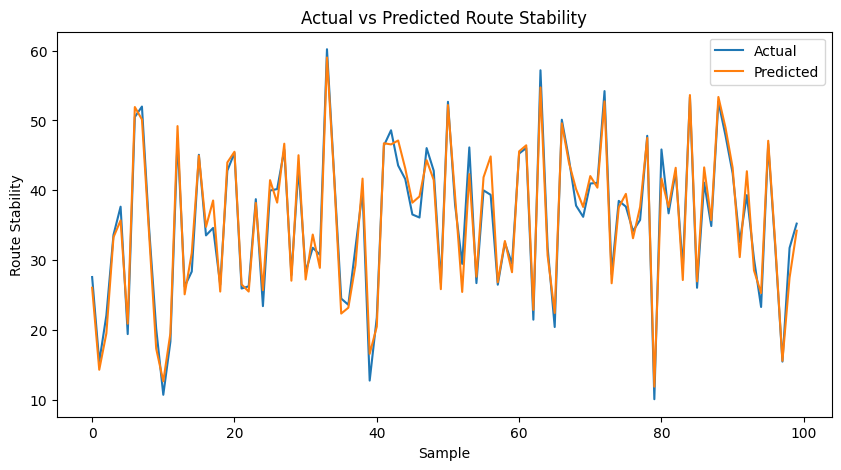

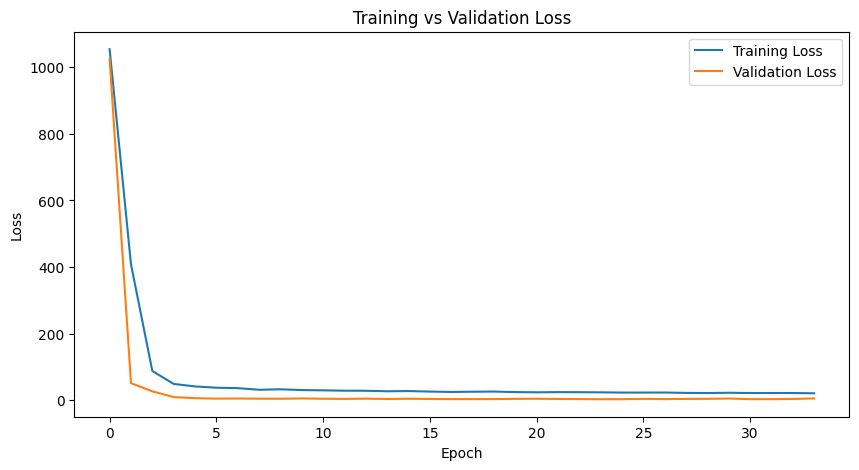


================ RANDOM INPUT TEST ================



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Route Stability Score: 46.45
Route Status: Moderately Stable

Model saved successfully!


In [5]:
# ============================================================
# ENHANCED DEEP LEARNING BASED ENERGY-AWARE ROUTING FOR MANET
# Better than LSTM for tabular routing data
# ============================================================

# Install:
# pip install tensorflow pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ============================================================
# STEP 1: GENERATE MANET DATASET
# ============================================================

np.random.seed(42)

num_samples = 5000

data = {
    "residual_energy": np.random.uniform(10, 100, num_samples),
    "node_speed": np.random.uniform(0, 20, num_samples),
    "distance": np.random.uniform(1, 250, num_samples),
    "link_quality": np.random.uniform(0.1, 1.0, num_samples),
    "queue_length": np.random.randint(1, 50, num_samples),
    "delay": np.random.uniform(1, 100, num_samples),
    "hop_count": np.random.randint(1, 15, num_samples),
}

df = pd.DataFrame(data)

# ============================================================
# STEP 2: REALISTIC TARGET FORMULA + NOISE
# ============================================================

noise = np.random.normal(0, 1.5, num_samples)

df["route_stability"] = (
    (df["residual_energy"] * 0.30)
    + ((1 / (df["node_speed"] + 1)) * 100 * 0.15)
    + (df["link_quality"] * 100 * 0.25)
    + ((1 / (df["delay"] + 1)) * 100 * 0.10)
    + ((1 / (df["distance"] + 1)) * 100 * 0.10)
    + ((1 / (df["queue_length"] + 1)) * 100 * 0.05)
    + ((1 / (df["hop_count"] + 1)) * 100 * 0.05)
    + noise
)

print("\nSample Dataset:\n")
print(df.head())

# ============================================================
# STEP 3: FEATURES
# ============================================================

X = df.drop("route_stability", axis=1)
y = df["route_stability"]

# ============================================================
# STEP 4: NORMALIZATION
# ============================================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 5: K-FOLD CROSS VALIDATION
# ============================================================

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = []
mse_scores = []
rmse_scores = []
r2_scores = []

best_model = None
best_r2 = -1
best_history = None
best_y_test = None
best_y_pred = None

fold = 1

for train_index, test_index in kfold.split(X_scaled):

    print(f"\n================ FOLD {fold} ================\n")

    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # ============================================================
    # BUILD ENHANCED MODEL
    # ============================================================

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(16, activation='relu'),

        Dense(1)
    ])

    # ============================================================
    # COMPILE
    # ============================================================

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    # ============================================================
    # CALLBACKS
    # ============================================================

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    # ============================================================
    # TRAIN
    # ============================================================

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # ============================================================
    # PREDICT
    # ============================================================

    y_pred = model.predict(X_test, verbose=0).flatten()

    # ============================================================
    # METRICS
    # ============================================================

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    mse_scores.append(mse)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_history = history
        best_y_test = y_test
        best_y_pred = y_pred

    fold += 1

# ============================================================
# STEP 6: FINAL RESULTS
# ============================================================

avg_mae = np.mean(mae_scores)
avg_mse = np.mean(mse_scores)
avg_rmse = np.mean(rmse_scores)
avg_r2 = np.mean(r2_scores)

print("\n==============================================")
print("FINAL CROSS VALIDATION RESULTS")
print("==============================================")
print(f"Average MAE  : {avg_mae:.4f}")
print(f"Average MSE  : {avg_mse:.4f}")
print(f"Average RMSE : {avg_rmse:.4f}")
print(f"Average R²   : {avg_r2:.4f}")

# ============================================================
# STEP 7: PLOT ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(best_y_test.values[:100], label='Actual')
plt.plot(best_y_pred[:100], label='Predicted')
plt.title("Actual vs Predicted Route Stability")
plt.xlabel("Sample")
plt.ylabel("Route Stability")
plt.legend()
plt.show()

# ============================================================
# STEP 8: LOSS GRAPH
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ============================================================
# STEP 9: RANDOM INPUT TEST
# ============================================================

print("\n================ RANDOM INPUT TEST ================\n")

random_input = np.array([[
    85.19,
    1.83,
    14.98,
    0.43,
    37,
    8.67,
    3
]])

random_input_scaled = scaler.transform(random_input)

prediction = best_model.predict(random_input_scaled, verbose=0)
predicted_score = prediction[0][0]

print("Predicted Route Stability Score:", round(predicted_score, 2))

if predicted_score > 50:
    print("Route Status: Highly Stable")
elif predicted_score > 35:
    print("Route Status: Moderately Stable")
else:
    print("Route Status: Poor Stability")

# ============================================================
# STEP 10: SAVE MODEL
# ============================================================

best_model.save("enhanced_manet_model.h5")

print("\nModel saved successfully!")


Sample Dataset:

   residual_energy  node_speed    distance  link_quality  queue_length  \
0        43.708611    7.872710   94.036564      0.549703            22   
1        95.564288    9.468713   83.895112      0.772072             2   
2        75.879455   17.090948   44.862324      0.606400             4   
3        63.879264    6.800088  152.209401      0.174972            45   
4        24.041678   17.392994  119.679416      0.267022            13   

       delay  hop_count  route_stability  
0  30.324834          8        31.859752  
1  56.504593          5        50.273194  
2  74.606487          9        42.950727  
3  59.995565         13        27.552827  
4  95.452717         12        15.397051  

================ FOLD 1 ================

MAE  : 1.3499
MSE  : 2.8799
RMSE : 1.6970
R²   : 0.9743

================ FOLD 2 ================

MAE  : 1.3870
MSE  : 3.0208
RMSE : 1.7381
R²   : 0.9720

================ FOLD 3 ================

MAE  : 1.3446
MSE  : 2.8024
RMSE : 1.6

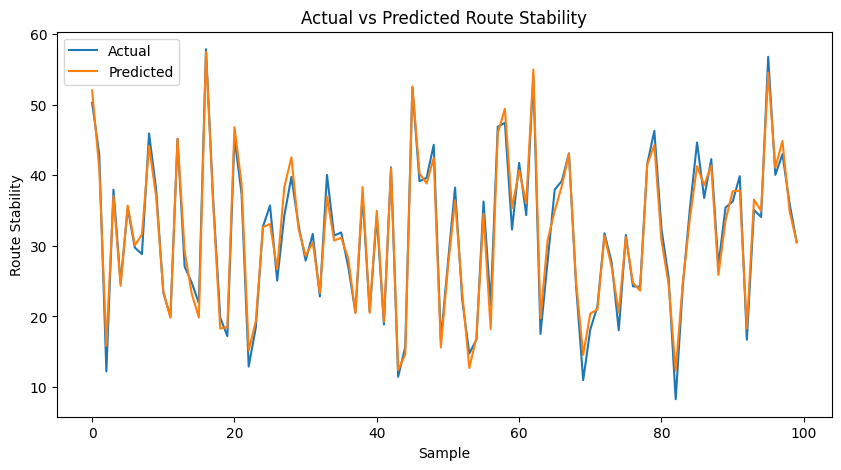

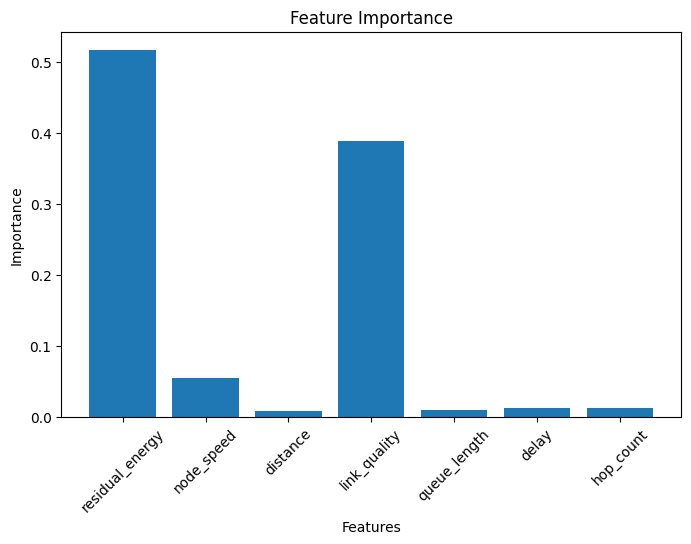


================ RANDOM INPUT TEST ================

Input Parameters:

Residual Energy : 85.19
Node Speed      : 1.83
Distance        : 14.98
Link Quality    : 0.43
Queue Length    : 37.0
Delay           : 8.67
Hop Count       : 3.0

Manual Formula Score: 44.65
XGBoost Prediction Score: 43.74
Prediction Error: 0.91
Route Status: Moderately Stable

Model and scaler saved successfully!

Excellent Model Performance


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [6]:
# ============================================================
# XGBOOST REGRESSOR FOR ENERGY-AWARE ROUTING IN MANET
# ============================================================

# Install:
# pip install xgboost pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import joblib

# ============================================================
# STEP 1: GENERATE MANET DATASET
# ============================================================

np.random.seed(42)

num_samples = 5000

data = {
    "residual_energy": np.random.uniform(10, 100, num_samples),
    "node_speed": np.random.uniform(0, 20, num_samples),
    "distance": np.random.uniform(1, 250, num_samples),
    "link_quality": np.random.uniform(0.1, 1.0, num_samples),
    "queue_length": np.random.randint(1, 50, num_samples),
    "delay": np.random.uniform(1, 100, num_samples),
    "hop_count": np.random.randint(1, 15, num_samples),
}

df = pd.DataFrame(data)

# ============================================================
# STEP 2: REALISTIC TARGET FORMULA + NOISE
# ============================================================

noise = np.random.normal(0, 1.5, num_samples)

df["route_stability"] = (
    (df["residual_energy"] * 0.30)
    + ((1 / (df["node_speed"] + 1)) * 100 * 0.15)
    + (df["link_quality"] * 100 * 0.25)
    + ((1 / (df["delay"] + 1)) * 100 * 0.10)
    + ((1 / (df["distance"] + 1)) * 100 * 0.10)
    + ((1 / (df["queue_length"] + 1)) * 100 * 0.05)
    + ((1 / (df["hop_count"] + 1)) * 100 * 0.05)
    + noise
)

print("\nSample Dataset:\n")
print(df.head())

# ============================================================
# STEP 3: FEATURE SELECTION
# ============================================================

X = df.drop("route_stability", axis=1)
y = df["route_stability"]

# Scaling (optional for consistency)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 4: K-FOLD CROSS VALIDATION
# ============================================================

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = []
mse_scores = []
rmse_scores = []
r2_scores = []

best_model = None
best_r2 = -1
best_y_test = None
best_y_pred = None
best_importance = None

fold = 1

for train_index, test_index in kfold.split(X_scaled):

    print(f"\n================ FOLD {fold} ================\n")

    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # ============================================================
    # XGBOOST MODEL
    # ============================================================

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=2,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    mse_scores.append(mse)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_y_test = y_test
        best_y_pred = y_pred
        best_importance = model.feature_importances_

    fold += 1

# ============================================================
# STEP 5: FINAL RESULTS
# ============================================================

avg_mae = np.mean(mae_scores)
avg_mse = np.mean(mse_scores)
avg_rmse = np.mean(rmse_scores)
avg_r2 = np.mean(r2_scores)

print("\n==============================================")
print("FINAL XGBOOST CROSS VALIDATION RESULTS")
print("==============================================")
print(f"Average MAE  : {avg_mae:.4f}")
print(f"Average MSE  : {avg_mse:.4f}")
print(f"Average RMSE : {avg_rmse:.4f}")
print(f"Average R²   : {avg_r2:.4f}")

# ============================================================
# STEP 6: ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(best_y_test.values[:100], label="Actual")
plt.plot(best_y_pred[:100], label="Predicted")
plt.title("Actual vs Predicted Route Stability")
plt.xlabel("Sample")
plt.ylabel("Route Stability")
plt.legend()
plt.show()

# ============================================================
# STEP 7: FEATURE IMPORTANCE
# ============================================================

feature_names = X.columns

plt.figure(figsize=(8, 5))
plt.bar(feature_names, best_importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# STEP 8: RANDOM INPUT TEST
# ============================================================

print("\n================ RANDOM INPUT TEST ================\n")

random_input = np.array([[
    85.19,
    1.83,
    14.98,
    0.43,
    37,
    8.67,
    3
]])

# Scale
random_input_scaled = scaler.transform(random_input)

# Predict
prediction = best_model.predict(random_input_scaled)
predicted_score = prediction[0]

# Manual score for verification
manual_score = (
    (random_input[0][0] * 0.30)
    + ((1 / (random_input[0][1] + 1)) * 100 * 0.15)
    + (random_input[0][3] * 100 * 0.25)
    + ((1 / (random_input[0][5] + 1)) * 100 * 0.10)
    + ((1 / (random_input[0][2] + 1)) * 100 * 0.10)
    + ((1 / (random_input[0][4] + 1)) * 100 * 0.05)
    + ((1 / (random_input[0][6] + 1)) * 100 * 0.05)
)

print("Input Parameters:\n")
print(f"Residual Energy : {random_input[0][0]}")
print(f"Node Speed      : {random_input[0][1]}")
print(f"Distance        : {random_input[0][2]}")
print(f"Link Quality    : {random_input[0][3]}")
print(f"Queue Length    : {random_input[0][4]}")
print(f"Delay           : {random_input[0][5]}")
print(f"Hop Count       : {random_input[0][6]}")

print("\nManual Formula Score:", round(manual_score, 2))
print("XGBoost Prediction Score:", round(predicted_score, 2))
print("Prediction Error:", round(abs(manual_score - predicted_score), 2))

# Route Interpretation
if predicted_score > 50:
    print("Route Status: Highly Stable")
elif predicted_score > 35:
    print("Route Status: Moderately Stable")
else:
    print("Route Status: Poor Stability")

# ============================================================
# STEP 9: SAVE MODEL
# ============================================================

joblib.dump(best_model, "xgboost_manet_model.pkl")
joblib.dump(scaler, "manet_scaler.pkl")

print("\nModel and scaler saved successfully!")

# ============================================================
# STEP 10: PERFORMANCE INTERPRETATION
# ============================================================

if avg_r2 > 0.95:
    print("\nExcellent Model Performance")
elif avg_r2 > 0.85:
    print("\nGood Model Performance")
else:
    print("\nModel Needs Improvement")